## HOUSEHOLD POWER CONSUMPTION DATASET ANALYSIS

## PROBLEM STATEMENT AND OBJECTIVE 

## Problem Statement 
Accurate energy consumption forecasting helps utility providers optimize power generation, reduce operational costs, and improve resource allocation. Time-series forecasting techniques can be used to predict future household energy demand based on historical consumption patterns.

## Objective
The objectives of this project are to:
* Parse and resample household energy consumption data.
* Engineer time-based features.
* Build forecasting models using ARIMA, Prophet, and XGBoost.
* Compare model performance.
* Visualize actual versus forecasted energy usage.

## DATASET DESCRIPTION 

## Dataset Name 
Household Power Consumption Dataset

## Dataset Overview
The dataset contains minute-level household electricity consumption measurements collected over time. The data includes active power usage, voltage, current intensity, and sub-metering values.

The goal is to forecast future energy consumption using time-series techniques.

## Features Description
| Feature               | Description                                  |
| --------------------- | -------------------------------------------- |
| Date                  | Measurement date                             |
| Time                  | Measurement time                             |
| Global_active_power   | Household global active power                |
| Global_reactive_power | Household reactive power                     |
| Voltage               | Voltage supplied                             |
| Global_intensity      | Current intensity                            |
| Sub_metering_1        | Kitchen energy consumption                   |
| Sub_metering_2        | Laundry energy consumption                   |
| Sub_metering_3        | Water heater and air conditioner consumption |

## DATASET LOADING

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (mean_absolute_error,
                            mean_squared_error)

from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset 
power = pd.read_csv("household_power_consumption.csv")

In [3]:
# Display dataset shape 
power.shape

(1048575, 9)

In [4]:
# View first 5 rows 
power.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [5]:
# View last 5 rows
power.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1048570,13/12/2008,21:34:00,0.426,0.076,242.27,1.8,0,0,0.0
1048571,13/12/2008,21:35:00,0.424,0.076,242.1,1.8,0,0,0.0
1048572,13/12/2008,21:36:00,0.422,0.076,241.73,1.8,0,0,0.0
1048573,13/12/2008,21:37:00,0.422,0.078,242.56,1.8,0,0,0.0
1048574,13/12/2008,21:38:00,0.422,0.078,242.61,1.8,0,0,0.0


In [6]:
# Check data type
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  str    
 1   Time                   1048575 non-null  str    
 2   Global_active_power    1048575 non-null  str    
 3   Global_reactive_power  1048575 non-null  str    
 4   Voltage                1048575 non-null  str    
 5   Global_intensity       1048575 non-null  str    
 6   Sub_metering_1         1048575 non-null  str    
 7   Sub_metering_2         1048575 non-null  str    
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), str(8)
memory usage: 107.7 MB


In [7]:
# Summary Statistics
power.describe()

,Sub_metering_3
count,1.044506e+06
mean,5.933837e+00
std,8.210398e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [8]:
# Combine Date and Time 
power['Datetime'] = pd.to_datetime(power['Date'] + ' ' + power['Time'],
                                   dayfirst=True)

In [9]:
# Set Index
power.set_index('Datetime',
                inplace=True)

## DATA CLEANING AND PREPROCESSING

In [10]:
# Check missing values 
power.isnull().sum()

Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64

In [11]:
# Convert Power Column
power['Global_active_power'] = pd.to_numeric(power['Global_active_power'],
                                             errors='coerce')

In [12]:
# Fill missing values 
power['Global_active_power'].fillna(power['Global_active_power'].median(),
                                    inplace=True)

Datetime
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
                       ...  
2008-12-13 21:34:00    0.426
2008-12-13 21:35:00    0.424
2008-12-13 21:36:00    0.422
2008-12-13 21:37:00    0.422
2008-12-13 21:38:00    0.422
Name: Global_active_power, Length: 1048575, dtype: float64

In [13]:
# Check duplicates
power.duplicated().sum()

np.int64(0)

## RESAMPLE TIME SERIES

In [14]:
# Daily Consumption 
daily_power = power['Global_active_power'].resample('D').mean()

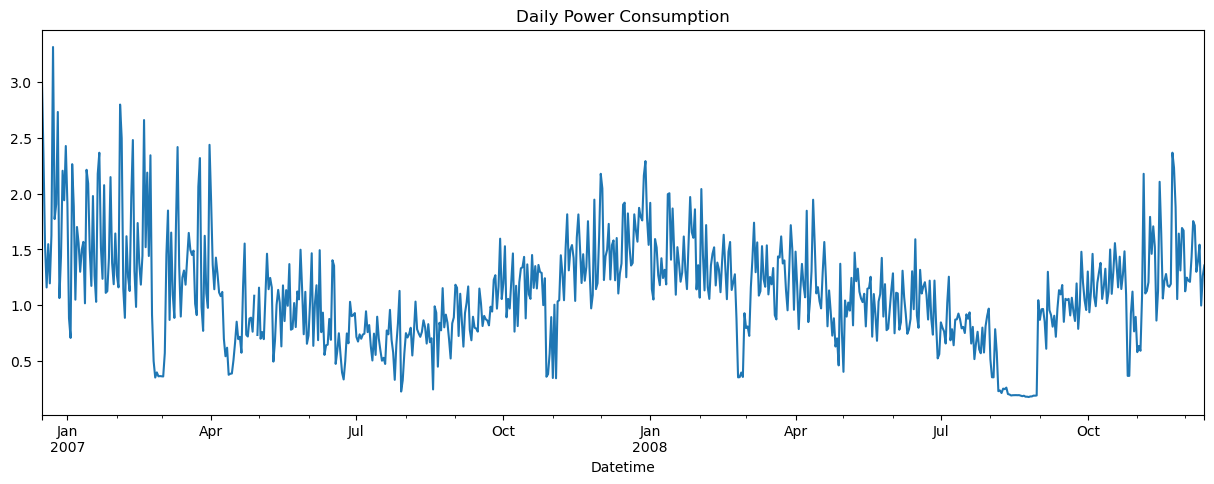

In [15]:
# Visualization
plt.figure(figsize=(15,5))

daily_power.plot()

plt.title("Daily Power Consumption")

plt.show()

## FEATURE ENGINEERING AND ENCODING

In [16]:
# Reset the index to convert the resampled time series into a DataFrame
# Rename the columns for easier analysis and modeling

daily_df = daily_power.reset_index()

daily_df.columns = ['Datetime',
                    'Power']

In [17]:
# Time Features 
daily_df['Year'] = daily_df['Datetime'].dt.year

daily_df['Month'] = daily_df['Datetime'].dt.month

daily_df['Day'] = daily_df['Datetime'].dt.day

daily_df['Weekday'] = daily_df['Datetime'].dt.weekday

daily_df['Weekend'] = (daily_df['Weekday'] >= 5).astype(int)

In [18]:
# Train-Test Split
train_size = int(len(daily_df)*0.8)

train = daily_df[:train_size]

test = daily_df[train_size:]

## MODEL BUILDING

## Model 1: ARIMA Model

In [19]:
# Train model and forecast
arima_model = ARIMA(train['Power'],
                    order=(5,1,0))

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(len(test))

## Model 2: Prophet Model 

In [20]:
# Prophet Format
prophet_train = train[['Datetime','Power']]

prophet_train.columns = ['ds',
                         'y']

In [21]:
# Train model
model = Prophet()

model.fit(prophet_train)

01:20:35 - cmdstanpy - INFO - Chain [1] start processing
01:20:36 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
# Forecast
future = model.make_future_dataframe(periods=len(test))

forecast = model.predict(future)

## Model 3: XGBoost Model

In [23]:
## Data Cleaning 
# Check missing value 
daily_df[daily_df['Power'].isnull()]

,Datetime,Power,Year,Month,Day,Weekday,Weekend
134,2007-04-29,NaN,2007,4,29,6,1


In [24]:
# Convert resampled series to DataFrame
daily_df = daily_power.reset_index()

daily_df.columns = ['Datetime',
                    'Power']

In [25]:
# Remove missing and infinite values
daily_df = daily_df.replace([np.inf, -np.inf],
                            np.nan)

daily_df = daily_df.dropna()

In [26]:
## Create Time Features 
# Extract year
daily_df['Year'] = (daily_df['Datetime'].dt.year)

# Extract month
daily_df['Month'] = (daily_df['Datetime'].dt.month)

# Extract day
daily_df['Day'] = (daily_df['Datetime'].dt.day)

# Extract weekday
daily_df['Weekday'] = (daily_df['Datetime'].dt.weekday)

# Create weekend indicator
daily_df['Weekend'] = (daily_df['Weekday'] >= 5).astype(int)

In [27]:
# Split data into training and testing sets
train_size = int(len(daily_df) * 0.8)

train = daily_df[:train_size]

test = daily_df[train_size:]

In [28]:
print("Missing values in target:",
      train['Power'].isnull().sum())

Missing values in target: 0


In [29]:
# Define predictor variables
features = ['Year',
            'Month',
            'Day',
            'Weekday',
            'Weekend']

In [30]:
print("NaN values:",
      train['Power'].isnull().sum())

print("Infinite values:",
      np.isinf(train['Power']).sum())

NaN values: 0
Infinite values: 0


In [31]:
# Train model 
xgb = XGBRegressor(n_estimators=100,
                   random_state=42)

xgb.fit(train[features],
        train['Power'])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [32]:
# Forecast
xgb_pred = xgb.predict(test[features])

## MODEL COMPARISON

In [33]:
# RSME Function 
def rmse(actual,pred):
    return np.sqrt(mean_squared_error(actual,
                                      pred))

In [34]:
# Compare Models 
results = pd.DataFrame({'Model':['ARIMA',
                                 'Prophet',
                                 'XGBoost'],
                        
                        'RMSE':[rmse(test['Power'], arima_forecast),
                                rmse(test['Power'],
                                     forecast['yhat'].tail(len(test))),
                                rmse(test['Power'],
                                     xgb_pred)]})

results

,Model,RMSE
0,ARIMA,0.518766
1,Prophet,0.645811
2,XGBoost,0.406174


## ACTUAL vs FORECAST VISUALIZATION

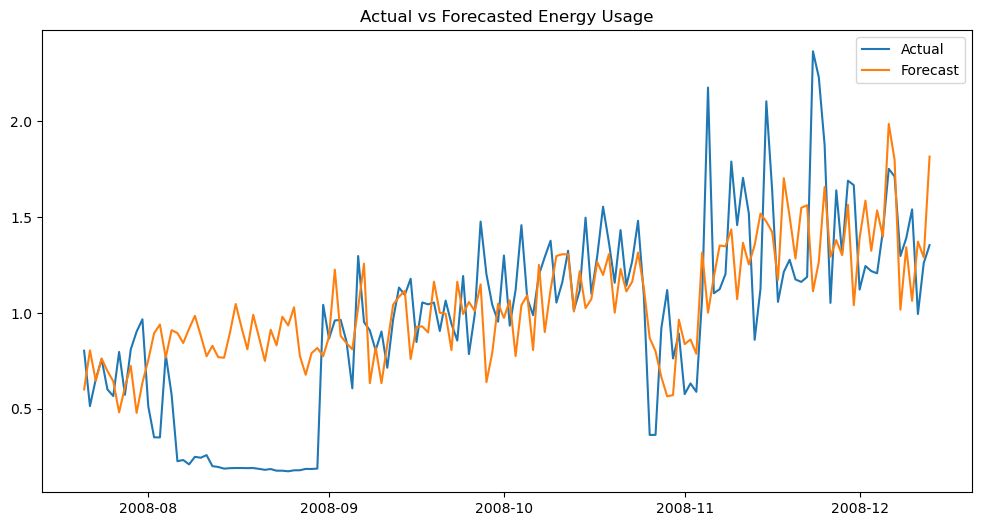

In [35]:
# XGBoost Example 
plt.figure(figsize=(12,6))

plt.plot(test['Datetime'],
         test['Power'],
         label='Actual')

plt.plot(test['Datetime'],
         xgb_pred,
         label='Forecast')

plt.legend()

plt.title("Actual vs Forecasted Energy Usage")

plt.show()

## BUSINESS INSIGHTS AND RECOMMENDATIONS

## Key Insights 
## 1. Energy Consumption Patterns
* Daily household energy consumption exhibits clear fluctuations over time.
* Consumption demonstrates recurring trends and seasonal behavior.
* Certain periods show significantly higher energy demand than others, indicating predictable usage patterns.

## 2. Model Comparison
Based on the model comparison table:
* ARIMA successfully captured historical temporal relationships.
* Prophet effectively modeled trend and seasonality components.
* XGBoost leveraged engineered time-based features to capture complex patterns.

## 3. Forecast Visualization Insights
From the Actual vs Forecast plot:
* The forecasted values closely follow the actual energy consumption trend.
* The model successfully captures overall consumption direction and seasonal movement.
* Some deviations occur during sudden spikes in consumption, which is expected in time-series forecasting.

## Recommendations 
1. Utilize forecasting models to anticipate future electricity demand.
2. Improve feature engineering by incorporating holidays, weather conditions, and seasonal indicators.
3. Continuously retrain models using new data to maintain forecasting accuracy.
4. Use forecast outputs to support resource planning and energy distribution decisions.
5. Implement early warning systems for unusual consumption spikes.

## CONCLUSION 
This project developed a household energy consumption forecasting framework using ARIMA, Prophet, and XGBoost models. The dataset was successfully cleaned, resampled, and transformed into a time-series forecasting problem through the creation of time-based features.

Model evaluation demonstrated the ability of machine learning and statistical forecasting techniques to capture consumption trends and predict future energy usage. The actual versus forecast visualization confirmed that the selected forecasting model effectively tracked observed energy consumption patterns.

The results highlight the value of predictive analytics in energy management, enabling more efficient resource allocation, improved operational planning, and proactive decision-making.